**Workshop notebooks:** [01 — Matching & Loading](https://colab.research.google.com/github/marlene-grabner/NetworkMedicine_Workshop/blob/main/01_matching_and_loading.ipynb)  &nbsp;·&nbsp; [02 — Overlay & Enrichment](https://colab.research.google.com/github/marlene-grabner/NetworkMedicine_Workshop/blob/main/02_overlay_enrichment.ipynb) &nbsp;·&nbsp;**03 — Bridging (you are here)**&nbsp;·&nbsp;[04 — Disease Modules (optional)](https://colab.research.google.com/github/marlene-grabner/NetworkMedicine_Workshop/blob/main/04_disease_modules_optional.ipynb)

# 03 — Bridging the Omics Layers

**Network Medicine Workshop · Kidney Disease · Part 3 of 3**

So far we've shown that your DE proteins form a connected module in the PPI network, and your DE metabolites form a connected module in the metabolite network. The real network-medicine question is: **do these two modules talk to each other?**

To answer that, we need a bridge between "gene/protein space" and "metabolite space" — KEGG compounds don't sit in the PPI network, but the enzymes that produce/consume them do. So:

1. Build a **metabolite → gene bridge** via KEGG (compound → enzyme (EC) → gene)
2. Merge it with your PPI network into one combined graph
3. Find the **shortest paths** between your PPI/protein module and your metabolite-linked genes
4. Rank genes by **betweenness centrality** — how often each one sits *between* the two sides — and keep the top connectors as the "bridge module", then enrich them
5. Check whether any bridge genes are known kidney-disease genes (Open Targets)

Requires Notebooks 1 and 2 to have already run.


**New here?** Run cells top to bottom with Shift+Enter (or the ▶ button), and wait for each one to finish before running the next — later cells depend on variables set by earlier ones. See Notebook 1 for a fuller intro to Colab if this is your first time.

## Setup — reload from Notebooks 1 & 2

As in Notebook 2, we start by reinstalling this notebook's packages, reconnecting to Drive, and reloading everything the earlier notebooks produced — this time the connected modules from Notebook 2 on top of the matched tables and networks from Notebook 1.

In [3]:
!pip install -q scipy networkx gprofiler-official requests mygene



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Reconnect to Drive, exactly as in the earlier notebooks — click through the permission prompt if it appears.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


With Drive connected, this cell reloads the network graphs and the module information Notebook 2 computed and saved.

In [ ]:
import os, sys, pickle, time
import pandas as pd
import numpy as np
import networkx as nx

BASE_DIR = "/content/drive/MyDrive/network_medicine_workshop"
PROC_DIR = os.path.join(BASE_DIR, "processed")

sys.path.insert(0, os.path.join(BASE_DIR, "helpers"))
_helper_file = os.path.join(BASE_DIR, "helpers", "nb3_helpers.py")
if not os.path.exists(_helper_file):
    # Rare, but can happen if Drive's sync lags behind a fresh download, or this notebook runs
    # before Notebook 1 has -- fetch this one helper file directly instead of leaving you stuck.
    import requests, importlib
    r = requests.get(f"https://raw.githubusercontent.com/marlene-grabner/NetworkMedicine_Workshop/main/helpers/nb3_helpers.py", timeout=30)
    r.raise_for_status()
    with open(_helper_file, "wb") as f:
        f.write(r.content)
    importlib.invalidate_caches()
    print(f"[recovered] fetched missing nb3_helpers.py directly")

from nb3_helpers import (build_bridge_live, search_disease, fetch_disease_targets, build_cost_graph,
                          select_metabolite_terminals, build_bridge_module, validate_bridge_module,
                          plot_bridge_flowchart)  # see helpers/nb3_helpers.py

PRIMARY_GENE_LAYER = "ppi"   # the protein/gene network we bridge INTO

with open(os.path.join(PROC_DIR, "modules.pkl"), "rb") as f:
    modules = pickle.load(f)

graphs = {}
for layer in ["ppi", "transcriptome", "metabolite"]:
    with open(os.path.join(PROC_DIR, f"graph_{layer}.pkl"), "rb") as f:
        graphs[layer] = pickle.load(f)

metabs_matched = pd.read_csv(os.path.join(PROC_DIR, "metabolites_matched.csv"), dtype={"kegg_id": str})
print("Reloaded modules, networks, and matched metabolites from", PROC_DIR)


Reloaded modules, networks, and matched metabolites from ./processed


From here on, **"your protein module"** means the connected proteomics module from Notebook 2, and **"your metabolites"** means the DE metabolites that made it into the metabolite network. The next cell pulls both out and reports their sizes — these are the two things we're about to bridge.

In [6]:
metab_ids = set(metabs_matched["kegg_id"].dropna().unique()) & set(graphs["metabolite"].nodes())

# the connected PPI module derived from your proteomics data (Notebook 2)
ppi_module_nodes = modules[PRIMARY_GENE_LAYER]["seed_nodes"]
print(f"Protein module (from proteomics, in the {PRIMARY_GENE_LAYER} network): {len(ppi_module_nodes)} nodes")
print(f"DE metabolites present in metabolite network: {len(metab_ids)}")


Protein module (from proteomics, in the ppi network): 141 nodes
DE metabolites present in metabolite network: 32


## Step 1 — Load the metabolite → gene bridge network

we use a **general-purpose bipartite network**: every KEGG compound linked to the human genes encoding the enzymes that act on it. It was precomputed once from KEGG's bulk `link` endpoint (two whole-database requests, joined locally) rather than queried per-compound, so it finishes in seconds rather than minutes — and, importantly, isn't scoped to any particular metabolite list. Swap in a different `DE_metabolites.csv` back in Notebook 1 and this same bridge still works.

`metabolite_gene_bridge.csv` was already downloaded automatically in Notebook 1's Step 0, so there's nothing to do here — this cell just loads it from Drive and subsets it to whichever metabolites are in play right now. If it's missing (most likely because Notebook 1 hasn't been run yet in this Drive account), it falls back to the old slow per-compound live-query path instead, with a warning, so this notebook still works standalone.


In [7]:
BRIDGE_CSV = os.path.join(BASE_DIR, "networks", "metabolite_gene_bridge.csv")

if os.path.exists(BRIDGE_CSV):
    full_bridge_df = pd.read_csv(BRIDGE_CSV, dtype=str)
    print(f"Loaded general-purpose bridge network: {len(full_bridge_df)} edges, "
          f"{full_bridge_df['kegg_id'].nunique()} compounds, {full_bridge_df['ncbi_gene_id'].nunique()} genes")

    # subset to whichever metabolites are actually in play for THIS run
    relevant = full_bridge_df[full_bridge_df["kegg_id"].isin(metab_ids)]
    bridge_cache = relevant.groupby("kegg_id")["ncbi_gene_id"].apply(set).to_dict()
    print(f"Subset to your {len(metab_ids)} current metabolites: "
          f"{len(bridge_cache)} have >=1 linked gene")
else:
    print("[warn] networks/metabolite_gene_bridge.csv not found — this usually means Notebook 1 "
          "hasn't been run yet in this Drive account (it downloads this file automatically). "
          "Falling back to slow live per-compound KEGG queries so this notebook still works standalone.")
    bridge_cache = build_bridge_live(metab_ids)   # one live KEGG query per compound — see helpers/nb3_helpers.py

n_with_genes = sum(1 for cid in metab_ids if bridge_cache.get(cid))
print(f"{n_with_genes}/{len(metab_ids)} metabolites linked to >=1 gene.")


Loaded general-purpose bridge network: 23030 edges, 2452 compounds, 2683 genes
Subset to your 32 current metabolites: 32 have >=1 linked gene
32/32 metabolites linked to >=1 gene.


## Step 2 — Merge into one combined graph, find shortest paths

We build a single graph: the PPI network, plus a bipartite layer of `metabolite –– gene` bridge edges. Then, we do **one multi-source Dijkstra call** from all protein-module nodes simultaneously (`scipy.sparse.csgraph.dijkstra`) to compute the shortest distances of our protein nodes to any other node. We then read off the distance to every metabolite-linked gene. This has to be efficient at 20k nodes, and this approach is. Otherwise, this computation could run for hours.


First, we work out exactly which genes are reachable in the network: for every DE metabolite, which of its bridged genes actually exist as nodes in the PPI network (a gene from KEGG's enzyme annotations isn't guaranteed to also appear in the PPI network).

In [8]:
G_gene = graphs[PRIMARY_GENE_LAYER].copy()

# metabolite-linked genes: union of all genes bridged from any DE metabolite, restricted to
# genes that are actually in the PPI network (otherwise there's nothing to path-find to)
metab_linked_genes = set()
metab_to_genes = {}
for cid in metab_ids:
    genes_here = bridge_cache.get(cid, set()) & set(G_gene.nodes())
    if genes_here:
        metab_to_genes[cid] = genes_here
        metab_linked_genes |= genes_here

print(f"{len(metab_linked_genes)} distinct metabolite-linked genes present in the {PRIMARY_GENE_LAYER} network, "
      f"covering {len(metab_to_genes)}/{len(metab_ids)} metabolites")


359 distinct metabolite-linked genes present in the ppi network, covering 31/32 metabolites


Now the actual pathfinding: we represent the network as a sparse adjacency matrix (the standard efficient representation for graph algorithms at this scale) and run **one multi-source Dijkstra call** from all protein-module seed nodes at once, rather than one Dijkstra run per seed. That single call is what keeps this fast even at ~20k nodes.

In [9]:
from scipy.sparse.csgraph import dijkstra

# Build sparse adjacency + node index maps
nodes = list(G_gene.nodes())
node_idx = {n: i for i, n in enumerate(nodes)}
A = nx.to_scipy_sparse_array(G_gene, nodelist=nodes, weight=None, format="csr")

ppi_seed_idx = [node_idx[n] for n in ppi_module_nodes if n in node_idx]
print(f"Running multi-source Dijkstra from {len(ppi_seed_idx)} protein-module seed nodes over "
      f"{len(nodes):,} nodes / {G_gene.number_of_edges():,} edges...")

t0 = time.time()
dist_matrix = dijkstra(csgraph=A, directed=False, indices=ppi_seed_idx, unweighted=True)
# dist_matrix shape: (n_seeds, n_nodes) — take the min over seeds = distance from the *nearest* module node
min_dist_from_ppi_module = dist_matrix.min(axis=0)
print(f"Done in {time.time()-t0:.1f}s")


Running multi-source Dijkstra from 141 protein-module seed nodes over 18,070 nodes / 306,915 edges...
Done in 0.4s


With distances computed for every node in the network, we can now read off the specific distance for each metabolite-linked gene and look at the shape of that distribution — this is the core result of the bridging analysis.

In [10]:
# Distance from each metabolite-linked gene to the nearest protein-module node
records = []
for cid, genes_here in metab_to_genes.items():
    for g in genes_here:
        d = min_dist_from_ppi_module[node_idx[g]]
        records.append({"kegg_id": cid, "bridge_gene": g, "distance_to_ppi_module": d})

bridge_df = pd.DataFrame(records)
bridge_df = bridge_df[np.isfinite(bridge_df["distance_to_ppi_module"])]  # drop unreachable
bridge_df = bridge_df.sort_values("distance_to_ppi_module")

print("Distribution of shortest-path distances (metabolite-linked gene -> nearest protein-module node):")
print(bridge_df["distance_to_ppi_module"].value_counts().sort_index())
bridge_df.head(15)


Distribution of shortest-path distances (metabolite-linked gene -> nearest protein-module node):
distance_to_ppi_module
0.0      2
1.0     76
2.0    290
3.0     20
4.0      3
Name: count, dtype: int64


,kegg_id,bridge_gene,distance_to_ppi_module
319,C00059,412,0.0
395,C00242,3251,0.0
0,C00039,3980,1.0
275,C00028,55349,1.0
135,C00019,54496,1.0
134,C00019,54904,1.0
133,C00019,10419,1.0
132,C00019,11019,1.0
129,C00019,4297,1.0
122,C00019,84787,1.0


**How to read this:** a distance of 1 means a metabolite-linked gene is a *direct interactor* of one of your DE proteins — about as tight a mechanistic link as network data can offer. Distance 2–3 still suggests a plausible shared pathway/complex. Longer distances (or "unreachable") suggest that particular metabolite's enzymes aren't operating anywhere near your proteomic signal.

Compare this observed distribution to what you'd expect from two random gene sets of the same sizes in this network if you want a formal significance statement — the degree-preserving permutation approach from Notebook 4 can be adapted for exactly this.


## Step 3 — Extract the bridge module (prize-collecting Steiner tree)

Rather than ranking individual genes by centrality, we now build an actual **minimum-cost tree**
connecting your protein module to your metabolites through the interactome — the same idea tools
like OmicsIntegrator use for exactly this kind of proteomics/metabolomics integration, usually
called a *prize-collecting Steiner forest*. Every node you want connected earns a **prize** for
being included; every edge costs something to traverse; the algorithm finds the cheapest way to
collect as many prizes as it can justify.

Two ingredients:
- **Prizes**, on the things you actually measured — your DE proteins (already network nodes) and
  your DE metabolites (represented by their single nearest bridging gene, since metabolites
  themselves aren't nodes in a protein-protein network). In a real dataset you'd weight these by
  significance (`-log10(p)` or `|log2FC|`); this workshop's synthetic DE lists don't carry those
  columns, so every node gets an equal prize of 1.0 — swap in your own weighting here if you have
  it.
- **Costs**, on edges, penalized by the degree of their endpoints (`sqrt(deg(u) * deg(v))`), so a
  path through a promiscuous hub protein is expensive and a path through specific, low-degree
  interactions is cheap. Same underlying problem as before — a handful of genome-scale hubs sit on
  a huge share of all shortest paths — but now it's priced in continuously rather than
  hard-excluding anything above a percentile.

**How this actually gets built:** first we force *every* terminal in — protein module plus one
representative gene per metabolite — via a minimum spanning tree over their pairwise
cheapest-path costs. That alone can't yet tell a genuinely well-connected terminal from one that
only got dragged in at enormous cost, so we then **prune**: walking in from each dangling branch
tip, if the cost of that branch exceeds the prize sitting at the end of it, we cut it — the actual
prize-collecting decision. That whole build (Steiner tree + pruning) is one call to
`build_bridge_module()` below; `PRUNE_STRICTNESS` is the one knob worth playing with — raise it to
keep more marginal branches, lower it to demand cheaper, tighter connections. Open
`helpers/nb3_helpers.py` if you want to see the pruning logic itself.

In [11]:
import mygene
mg = mygene.MyGeneInfo()

PRUNE_STRICTNESS = 1.0   # a terminal's own branch survives if its cost is within this many "prizes" -- lower = stricter pruning

protein_terminals = set(ppi_module_nodes) & set(G_gene.nodes())
cost_nodes, cost_idx, A_cost, degrees = build_cost_graph(G_gene)
metab_terminal_gene, metab_terminals = select_metabolite_terminals(
    cost_nodes, cost_idx, A_cost, protein_terminals, metab_to_genes
)
terminals = protein_terminals | metab_terminals
prize = {n: 1.0 for n in terminals}   # uniform -- see markdown above; weight by -log10(p) or |log2FC| if you have it

t0 = time.time()
bridge_tree = build_bridge_module(cost_nodes, cost_idx, A_cost, protein_terminals, metab_terminals,
                                   prize, PRUNE_STRICTNESS)
print(f"Built in {time.time()-t0:.1f}s")

bridge_module_nodes = set(bridge_tree.nodes())
observed_cost = sum(d["cost"] for _, _, d in bridge_tree.edges(data=True))
connector_genes = bridge_module_nodes - terminals
n_terminals_kept = len(bridge_module_nodes & terminals)

symbols = mg.querymany(list(connector_genes), scopes="entrezgene", fields="symbol",
                        species="human", returnall=True)
sym_lookup = {h["query"]: h.get("symbol", h["query"]) for h in symbols["out"]}

print(f"Bridge module: {len(bridge_module_nodes)} genes total "
      f"({n_terminals_kept}/{len(terminals)} terminals kept, {len(connector_genes)} newly-surfaced "
      f"connector genes), total cost {observed_cost:.1f}")
print("Newly-surfaced connector genes (not among your original DE proteins or metabolite-linked genes):")
print(sorted(sym_lookup.get(g, g) for g in connector_genes))


Built in 0.8s
Bridge module: 356 genes total (165/168 terminals kept, 191 newly-surfaced connector genes), total cost 110.2
Newly-surfaced connector genes (not among your original DE proteins or metabolite-linked genes):
['ABCC1', 'ABCG8', 'ACOT1', 'ADGRF5', 'ADRB2', 'AGAP2', 'ALPK1', 'API5', 'ARPC1A', 'ATG5', 'AZIN2', 'BEX4', 'BICDL2', 'C12orf57', 'C1orf146', 'C2orf68', 'C3', 'C4orf33', 'C9', 'CAMKMT', 'CAPG', 'CAPS', 'CARMIL2', 'CCDC134', 'CCDC171', 'CCDC27', 'CCL15', 'CCN4', 'CCR9', 'CD59', 'CDC73', 'CDKL5', 'CHDH', 'CHST4', 'CHST6', 'CIMAP1A', 'CLDN17', 'COL21A1', 'COLGALT1', 'COPZ1', 'COPZ2', 'COX7C', 'CR2', 'CRYGN', 'CST8', 'CTSC', 'CTSO', 'DBR1', 'DCPH1', 'DDAH1', 'DEFB118', 'DEPDC5', 'DHRS2', 'DLG5', 'DNAH6', 'DSC1', 'DSG2', 'DUSP3', 'EEF1B2', 'ENSA', 'ESPN', 'FKBP9', 'FN3KRP', 'FOXD3', 'G2E3', 'GLRX', 'GNB1L', 'GOLPH3', 'GOLPH3L', 'GPR143', 'GPR18', 'GPR20', 'GPT', 'GPT2', 'HLCS', 'HNRNPA1L2', 'HOGA1', 'HS6ST3', 'HSD3B2', 'HSPB9', 'IDE', 'IGKV1D-13', 'IQCH', 'JAM2', 'KCTD16', 

### Validating the module against a null model

A tree connecting every terminal will always exist — the real question is whether *this* one is
more plausible than what you'd get from an arbitrary same-size, similarly-connected gene set.
Following the same degree-matched permutation logic as Notebook 4 (Menche et al. 2015):
`validate_bridge_module()` draws degree-matched random terminal sets the same sizes as your real
protein and metabolite terminals, rebuilds a bridge module for each exactly the same way, and
compares the real module's **total cost** to that null distribution. A genuine, specific mechanism
should be *cheaper* to connect (fewer hops, through lower-degree, more specific interactions) than
an arbitrary same-size gene set — so a negative z-score (real module cheaper than random) is the
result you're hoping for.

In [12]:
N_PERMUTATIONS = 100

null_costs, z_score, p_value = validate_bridge_module(
    G_gene, cost_nodes, cost_idx, A_cost, protein_terminals, metab_terminals,
    observed_cost, N_PERMUTATIONS, strictness=PRUNE_STRICTNESS,
)

print(f"Observed bridge cost: {observed_cost:.1f}")
print(f"Null (random, degree-matched) cost: {null_costs.mean():.1f} +/- {null_costs.std():.1f}")
print(f"z = {z_score:.2f}, p = {p_value:.4f}")
if z_score < 0:
    print("Your bridge module connects its terminals more cheaply than a random same-size, "
          "same-degree gene set -- consistent with a real, specific connecting mechanism rather "
          "than an artifact of network density.")
else:
    print("Your bridge module isn't noticeably cheaper than a random comparison -- treat it as "
          "exploratory rather than a strong signal.")


100 permutations in 88s
Observed bridge cost: 110.2
Null (random, degree-matched) cost: 131.2 +/- 3.0
z = -6.91, p = 0.0000
Your bridge module connects its terminals more cheaply than a random same-size, same-degree gene set -- consistent with a real, specific connecting mechanism rather than an artifact of network density.


## Step 4 — Enrichment of the bridge module

Same g:Profiler approach as Notebook 2, now applied to the compelte bridge module we just ranked out — this tells us what biological processes/pathways the genes connecting the proteome and metabolome are actually involved in.

In [13]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)

if len(bridge_module_nodes) >= 3:
    bridge_enrichment = gp.profile(
        organism="hsapiens", query=list(bridge_module_nodes), sources=["GO:BP", "KEGG", "REAC"],
    ).sort_values("p_value")
    display(bridge_enrichment[["source", "name", "p_value", "term_size", "intersection_size"]].head(15))
    bridge_enrichment.to_csv(os.path.join(PROC_DIR, "bridge_module_enrichment.csv"), index=False)
else:
    print("Bridge module too small for enrichment — try increasing N_CLOSEST above.")
    bridge_enrichment = pd.DataFrame()


,source,name,p_value,term_size,intersection_size
0,REAC,Developmental Biology,9.823597e-12,1394,79
1,REAC,Axon guidance,1.022651e-11,543,46
2,KEGG,Cornified envelope formation,1.186055e-11,215,29
3,REAC,Nervous system development,1.236270e-11,568,47
4,REAC,Regulation of expression of SLITs and ROBOs,1.277028e-11,171,26
5,REAC,Metabolism of amino acids and derivatives,1.718490e-11,363,37
6,REAC,Eukaryotic Translation Elongation,1.906724e-11,94,20
7,REAC,Peptide chain elongation,9.825760e-11,90,19
8,REAC,Viral mRNA Translation,9.825760e-11,90,19
10,REAC,Selenocysteine synthesis,2.265758e-10,94,19


Now look at the enrichment for only those genes which connect the metabolite and protein space
— DE metabolites and proteins themselves aren't included.

Heads up: this can easily come back empty. `gp.profile()` only *reports* terms whose corrected
p-value clears its significance threshold (`g:SCS`) — everything else is silently dropped, not an
error. The full module above is dominated by extremely well-annotated complement genes (`C3`,
`CFH`, `C5`, ...) that carry a lot of enrichment on their own; strip those out and you're left with
a smaller, more heterogeneous set of newly-surfaced genes that may not individually share enough
annotated pathway membership to survive correction. `all_results=True` below shows the best
candidate terms either way, with a `significant` column so you can see which (if any) actually
cleared the bar.

In [14]:
if len(connector_genes) >= 3:
    connector_enrichment = gp.profile(
        organism="hsapiens", query=list(connector_genes), sources=["GO:BP", "KEGG", "REAC"],
        all_results=True,
    ).sort_values("p_value")
    display(connector_enrichment[["source", "name", "p_value", "significant", "term_size", "intersection_size"]].head(15))
    connector_enrichment.to_csv(os.path.join(PROC_DIR, "connector_genes_enrichment.csv"), index=False)
    if not connector_enrichment["significant"].any():
        print("None of these clear the corrected significance threshold -- the table above is "
              "the closest candidates, not a confirmed enrichment. Worth a manual look, not a claim.")
else:
    print("Too few connector genes for enrichment.")
    connector_enrichment = pd.DataFrame()


,source,name,p_value,significant,term_size,intersection_size
0,KEGG,Cornified envelope formation,0.034739,True,215,9
1,KEGG,Arginine biosynthesis,0.149924,False,23,3
2,GO:BP,hemopoiesis,0.228371,False,971,20
3,GO:BP,alpha-amino acid metabolic process,0.254942,False,186,8
4,GO:BP,proteinogenic amino acid metabolic process,0.288506,False,142,7
5,GO:BP,L-amino acid metabolic process,0.301301,False,143,7
6,GO:BP,desmosome organization,0.312902,False,14,3
7,GO:BP,sulfur compound transport,0.325995,False,65,5
14,GO:BP,protein targeting to Golgi apparatus,0.340048,False,3,2
12,GO:BP,"CD8-positive, gamma-delta intraepithelial T ce...",0.340048,False,3,2


## Step 5 — Is any of this targetable? (Open Targets)

Last check: do any of the bridge-module genes already have known associations with kidney disease — and by extension, known drugs? We query the [Open Targets Platform](https://platform.opentargets.org/) public API (no key required). First we resolve a disease name to its EFO ID, then pull associated targets, then intersect with our bridge module.


In [15]:
DISEASE_QUERY = "chronic kidney disease"   # change to match your phenotype of interest

hits = search_disease(DISEASE_QUERY)   # GraphQL call — see helpers/nb3_helpers.py
for h in hits:
    print(h["id"], "-", h["name"])


MONDO_0005300 - chronic kidney disease
EFO_0009909 - stage 5 chronic kidney disease
MONDO_0004691 - autosomal dominant polycystic kidney disease
MONDO_0054842 - polycystic kidney disease 6 with or without polycystic liver disease
MONDO_0013131 - polycystic kidney disease 2


Pick the disease ID that best matches your phenotype from the list printed above — by default the cell below just takes the top hit. The next cell then pulls every gene Open Targets associates with that disease.

In [16]:
# Pick the EFO ID that best matches your phenotype from the printed list above
EFO_ID = hits[0]["id"] if hits else None
print("Using disease ID:", EFO_ID)

disease_gene_symbols = fetch_disease_targets(EFO_ID) if EFO_ID else set()   # see helpers/nb3_helpers.py
print(f"Pulled {len(disease_gene_symbols)} disease-associated genes from Open Targets")


Using disease ID: MONDO_0005300
Pulled 500 disease-associated genes from Open Targets


Finally, we check whether any gene in our bridge module already shows up in that disease-association list. Open Targets speaks in gene symbols, while our bridge module is in NCBI Gene IDs, so we first translate using the symbol table saved back in Notebook 1.

In [17]:
# Our bridge module is in NCBI Gene IDs; Open Targets returns gene symbols, so map back via
# the matched-symbol table saved in Notebook 1 (union of transcript + protein matches).
degs_matched = pd.read_csv(os.path.join(PROC_DIR, "degs_matched.csv"), dtype={"ncbi_gene_id": str})
proteins_matched = pd.read_csv(os.path.join(PROC_DIR, "proteins_matched.csv"), dtype={"ncbi_gene_id": str})
id_to_symbol = dict(zip(proteins_matched["ncbi_gene_id"], proteins_matched["matched_symbol"]))
id_to_symbol.update(dict(zip(degs_matched["ncbi_gene_id"], degs_matched["matched_symbol"])))

bridge_symbols = {id_to_symbol.get(g, g) for g in bridge_module_nodes}
overlap = bridge_symbols & disease_gene_symbols

print(f"Bridge module genes with a prior kidney-disease association: {len(overlap)} / {len(bridge_symbols)}")
if overlap:
    print(sorted(overlap))


Bridge module genes with a prior kidney-disease association: 2 / 356
['NADSYN1', 'NUDT5']


Independently-generated proteomic and metabolomic signals converge on a specific, connected set of genes in the interactome — and a subset of those genes already have documented kidney-disease associations (and, worth checking manually on the [Open Targets](https://platform.opentargets.org/) or [DrugBank](https://go.drugbank.com/) site, some may have approved or investigational compounds against them). That's the difference between "we found a correlation" and "we found a mechanism with a foothold for intervention."


## Step 6 — Final visualization

A flow diagram from one omics layer to the other: **proteins on the left**, **metabolites on the
right**, and your prize-collecting bridge module's connector genes tiered in columns in between by
how many hops they sit from the protein module. Reading left to right tells you how directly (or
indirectly) each metabolite's signal actually reaches your protein module, instead of collapsing
that into a single "connected or not."

The two parameters below are the only things worth tuning here — how many hop-tiers to draw at
most, and how large the figure is allowed to get before it automatically falls back to fewer hops.
Everything else (hop-tiering, the fallback logic, building the node/edge sets, labeling, drawing)
is one call to `plot_bridge_flowchart()` in `helpers/nb3_helpers.py` — open it if you want to see
how any of it works.

Capping the figure at 1 hop(s) from the protein module to keep it readable (213 connector genes would appear at up to 3 hops).
20 metabolite(s) not pictured -- their bridge lies beyond 1 hop(s) from the protein module, or was pruned in Step 3.


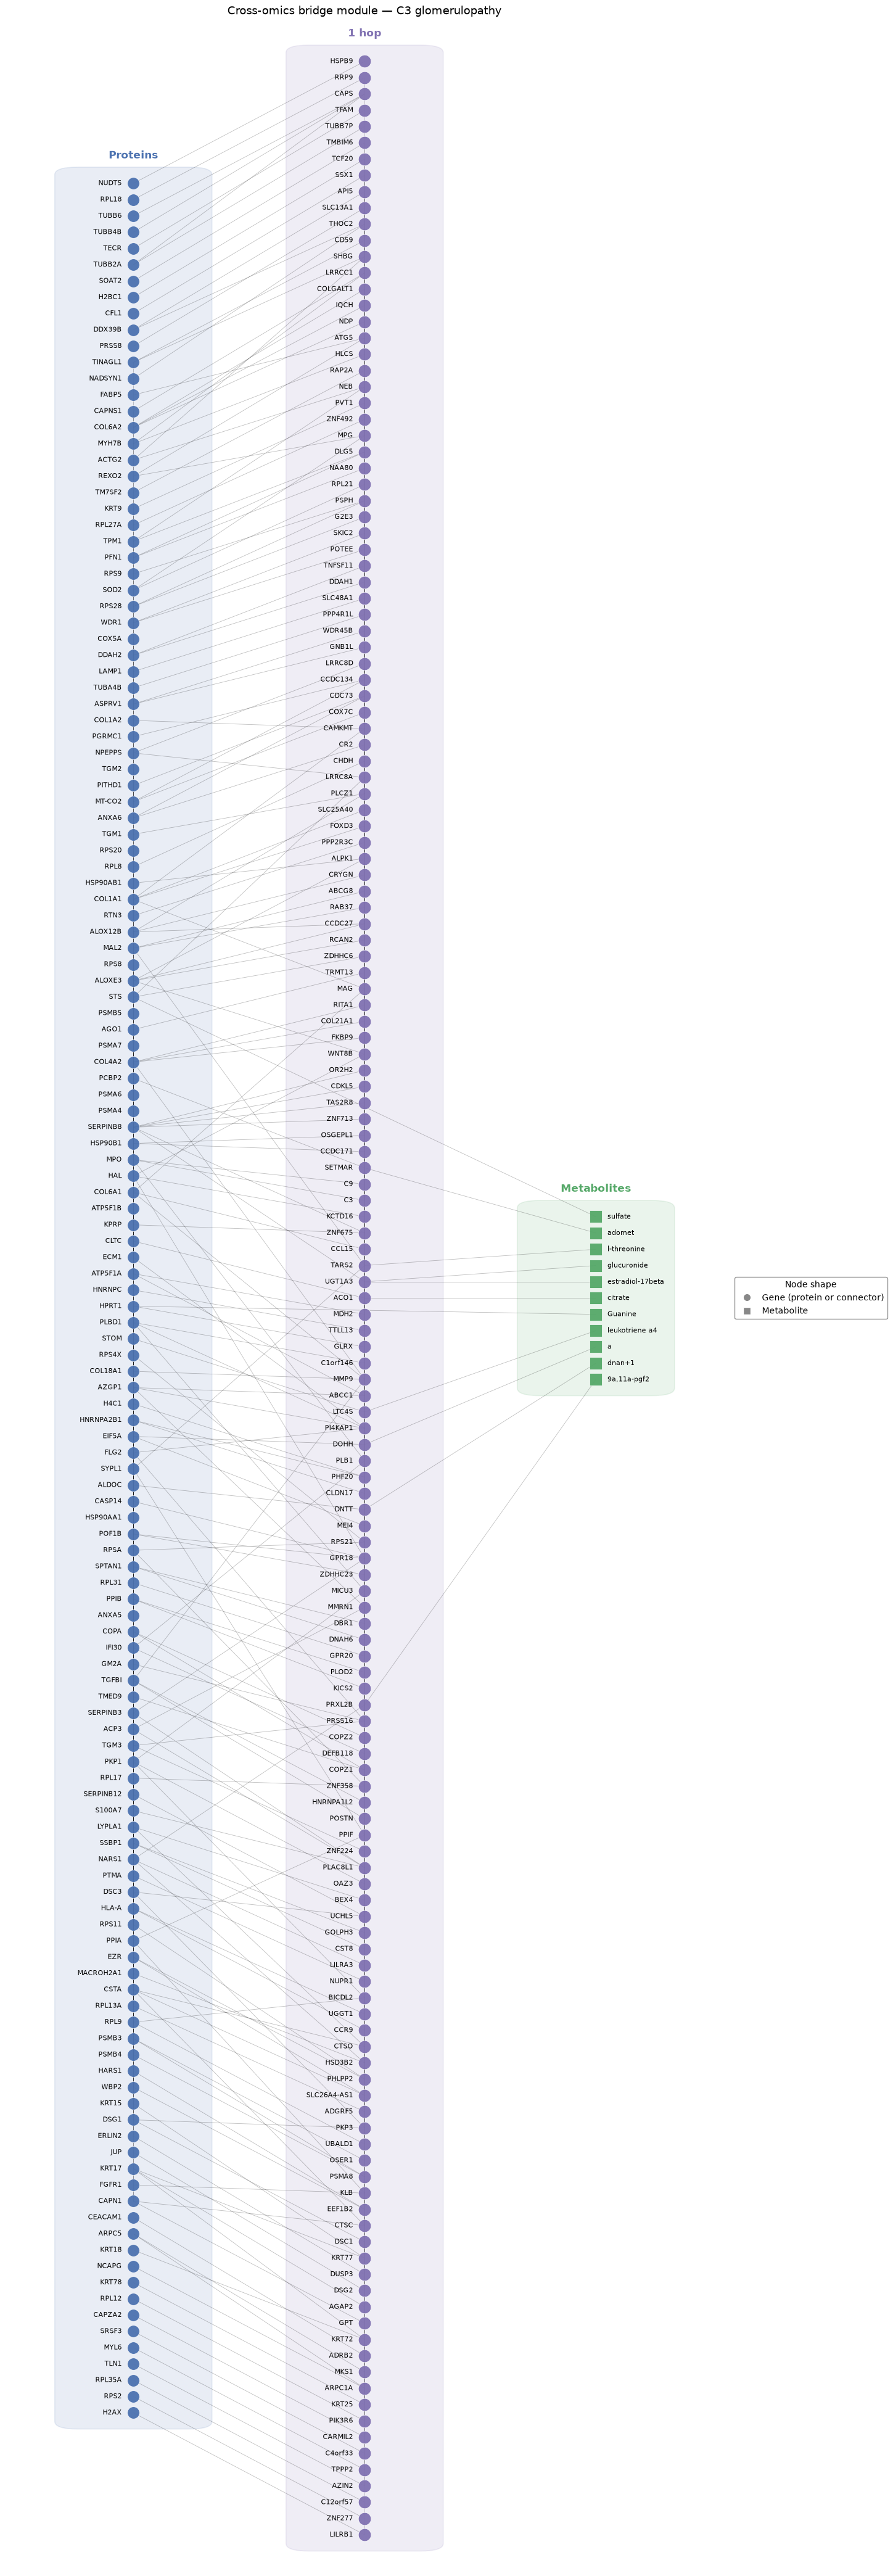

In [18]:
MAX_HOP_CAP = 3            # "direct" (1 hop) / "one in-between hop" (2) / "two in-between hops" (3)
EXPLOSION_THRESHOLD = 70   # total connector nodes allowed across all drawn hop-tiers

plot_bridge_flowchart(
    bridge_tree, protein_terminals, bridge_module_nodes, metab_terminal_gene,
    metabs_matched, id_to_symbol, sym_lookup, mg,
    max_hop_cap=MAX_HOP_CAP, explosion_threshold=EXPLOSION_THRESHOLD,
    save_path=os.path.join(PROC_DIR, "bridge_module.png"),
)


Finally, we save the bridge module itself (not just the picture) — the optional Notebook 4 uses it as the richest available representation of "your" disease module when comparing against other diseases.

In [19]:
# Save the bridge module — Notebook 4 (optional) can use this as "your" module for disease comparisons
with open(os.path.join(PROC_DIR, "bridge_module.pkl"), "wb") as f:
    pickle.dump(bridge_module_nodes, f)


---
**Optional next step:** `04_disease_modules_optional.ipynb` picks this bridge module back up and asks how it relates, network-topologically, to two *other* diseases.


**Workshop notebooks:** [01 — Matching & Loading](https://colab.research.google.com/github/marlene-grabner/NetworkMedicine_Workshop/blob/main/01_matching_and_loading.ipynb)  &nbsp;·&nbsp; [02 — Overlay & Enrichment](https://colab.research.google.com/github/marlene-grabner/NetworkMedicine_Workshop/blob/main/02_overlay_enrichment.ipynb) &nbsp;·&nbsp;**03 — Bridging (you are here)**&nbsp;·&nbsp;[04 — Disease Modules (optional)](https://colab.research.google.com/github/marlene-grabner/NetworkMedicine_Workshop/blob/main/04_disease_modules_optional.ipynb)